# Single value deconvolution of replication timing

May 6, 2024

Goal: Can we deconvolve a single value (position in S/G2M) where replication occurs for each 10k window?


In [4]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [5]:
from src.mnase_replication_timing_analysis import MNaseOriginAnalysis

mnase_analysis_rep1 = MNaseOriginAnalysis(replicate=1)
mnase_analysis_rep1.compute_bin_curves()

mnase_analysis_rep2 = MNaseOriginAnalysis(replicate=2)
mnase_analysis_rep2.compute_bin_curves()


1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 00:02:23.817
1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 00:02:42.979


In [6]:
# Normalize data and compute raw data replicating timings
mnase_analysis_rep1.normalize_and_compute_raw_replication_timing()
mnase_analysis_rep2.normalize_and_compute_raw_replication_timing()

In [7]:
from src.stepwise_replication_solver import StepReplicationChromatinDeconvolveSolver
solver = StepReplicationChromatinDeconvolveSolver(mnase_analysis_rep1, mnase_analysis_rep2)

In [548]:
solver.deconvolve_chr_all_bins(10)

40/368 - 00:00:21.750
80/368 - 00:00:51.324
120/368 - 00:01:17.194
160/368 - 00:01:42.756
200/368 - 00:02:08.976
280/368 - 00:02:58.196
320/368 - 00:03:24.974
360/368 - 00:03:52.939


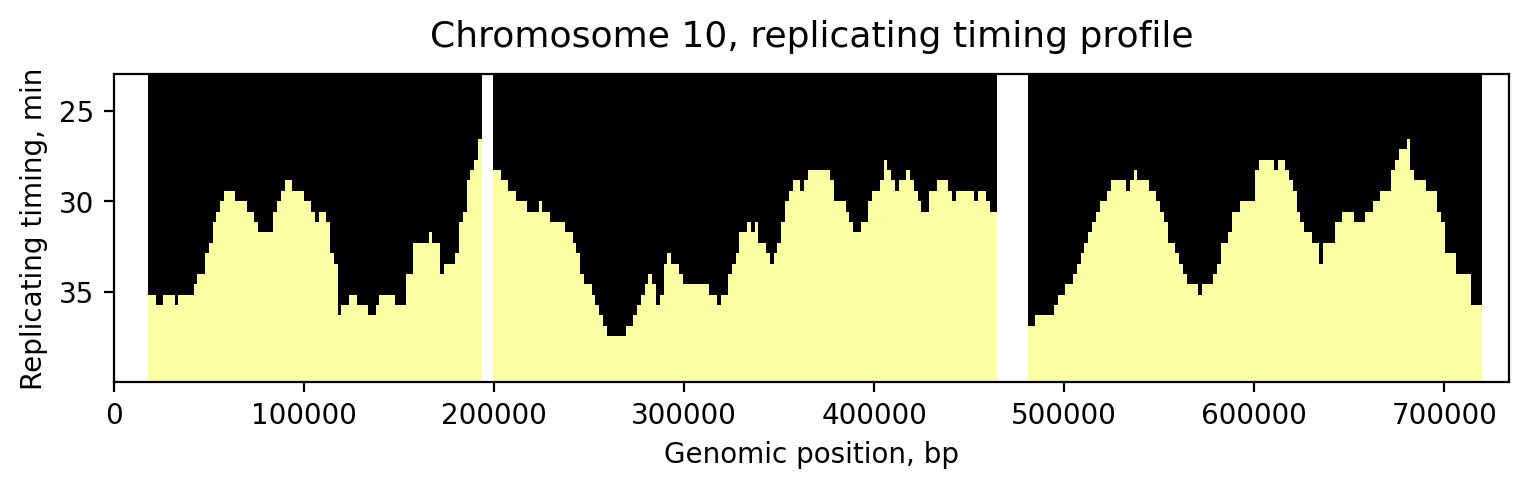

In [583]:
solver.plot_deconvolved_chrom_f()

In [1]:
# Instead of dropping genes, let's interpolate the replication timing from neighbors

In [532]:
solver.deconvolve_all_chromosomes()

Chromosome 1
0/111 - 00:00:00.666
40/111 - 00:00:27.059
done. - 00:01:02.242
Chromosome 2
40/402 - 00:00:23.230
80/402 - 00:00:50.155
120/402 - 00:01:15.339
160/402 - 00:01:38.466
200/402 - 00:02:06.585
240/402 - 00:02:33.438
280/402 - 00:02:59.918
320/402 - 00:03:27.729
360/402 - 00:03:53.686
400/402 - 00:04:20.608
done. - 00:05:24.517
Chromosome 3
0/154 - 00:00:00.659
80/154 - 00:00:45.870
120/154 - 00:01:12.775
done. - 00:06:58.697
Chromosome 4
40/761 - 00:00:21.706
80/761 - 00:00:48.756
120/761 - 00:01:15.253
160/761 - 00:01:41.527
200/761 - 00:02:09.117
240/761 - 00:02:37.172
280/761 - 00:02:57.633
360/761 - 00:03:46.545
400/761 - 00:04:13.329
480/761 - 00:05:01.362
520/761 - 00:05:24.270
560/761 - 00:05:47.308
640/761 - 00:06:36.844
680/761 - 00:07:03.226
720/761 - 00:07:29.013
done. - 00:14:56.999
Chromosome 5
40/284 - 00:00:25.813
80/284 - 00:00:54.085
120/284 - 00:01:20.448
160/284 - 00:01:47.245
200/284 - 00:02:14.431
240/284 - 00:02:37.488
280/284 - 00:03:00.062
done. - 00:1

In [534]:
solver.all_chrom_fs_df.to_csv('output/deconvolved_all_chr_replication_profile_delta_model.csv')

In [8]:
# Take a look at chromosome 1, how many genes are removed, interpolate replicating timing
# so we do not need to remove any genes..


solver.deconvolve_chr_all_bins(1)

0/111 - 00:00:00.767
40/111 - 00:00:27.726


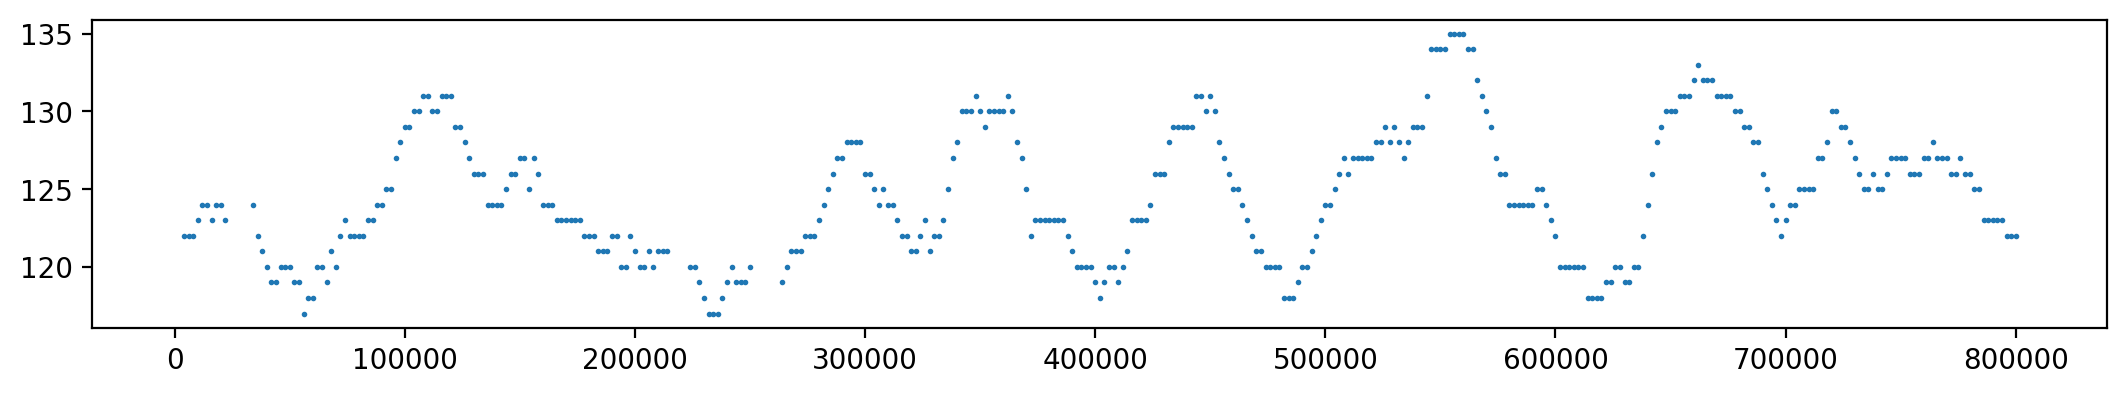

In [61]:
repl_profile = pd.read_csv('datasets/computed_mnase/'\
			'deconvolved_all_chr_replication_profile_delta_model.csv')
repl_profile = repl_profile.set_index(['chr', 'start']).round()
    
repl_prof_values = repl_profile.loc[2].idxmax(axis=1).astype(float)


plt.figure(figsize=(13, 2))
plt.scatter(repl_prof_values.index, repl_prof_values.values, s=1)


In [62]:
# Loop through the replication profile values, when a string of nans are reached
# record the start and end, then interpolate between before the start and after the end
k = len(repl_prof_values.values)

startna = None
lastna = None
interpolate_start = None
interpolate_end = None

interpolate_tuples = []

for i in range(0, k):
    prior_index = repl_prof_values.index[i-1]
    prior_value = repl_prof_values.values[i-1]
    index = repl_prof_values.index[i]
    value = repl_prof_values.values[i]

    if np.isnan(value):
        if startna is None:
            startna = index
            interpolate_start = prior_value
    elif not startna is None:
        lastna = prior_index
        interpolate_end = value

        tup = (startna, lastna, interpolate_start, interpolate_end)
        
        interpolate_tuples.append(tup)

        startna = None
        lastna = None
        interpolate_start = None
        interpolate_end = None

tup = (startna, lastna, interpolate_start, interpolate_end)
interpolate_tuples.append(tup)



In [63]:
interpolate_tuples

[(0, 2000, nan, 122.0),
 (24000, 32000, 123.0, 124.0),
 (216000, 222000, 121.0, 120.0),
 (252000, 262000, 120.0, 119.0),
 (802000, None, 122.0, None)]

In [64]:
repl_prof_values

start
0           NaN
2000        NaN
4000      122.0
6000      122.0
8000      122.0
          ...  
794000    123.0
796000    122.0
798000    122.0
800000    122.0
802000      NaN
Length: 402, dtype: float64